# WiniCari — Exploration des Données IA

In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

from src.data.db import client
import matplotlib.pyplot as plt

In [2]:
from src.data.db import get_db

db_winicari = get_db("winicari")
db_gps = get_db("Historique_pos")

## Cartographie de la base de données

In [3]:
import pandas as pd

SYSTEM = {"admin", "config", "local"}

all_dbs = client.list_database_names()
print("All databases:", all_dbs)

rows = []

for name in all_dbs:
    if name in SYSTEM:
        continue
    n_collections = len(client[name].list_collection_names())
    rows.append({"database": name,"n_collections": n_collections})

landscape = pd.DataFrame(rows)
landscape

All databases: ['Historique_pos', 'admin', 'config', 'local', 'winicari']


,database,n_collections
0,Historique_pos,1603
1,winicari,55


In [4]:
# winicari collection inventory
inv = []

for col in db_winicari.list_collection_names():
    count = db_winicari[col].estimated_document_count()
    inv.append({"collection": col,"est_count": count})

winicari_inv = pd.DataFrame(inv)
winicari_inv = winicari_inv.sort_values(
    by="est_count",
    ascending=False
).reset_index(drop=True)

print("Number of collections:", len(winicari_inv))
print("Non-empty collections:", (winicari_inv["est_count"] > 0).sum())
print("Total estimated documents:", winicari_inv["est_count"].sum())

winicari_inv

Number of collections: 55
Non-empty collections: 43
Total estimated documents: 214099


,collection,est_count
0,position,64431
1,price,51660
2,details_OLD,25306
3,session_ouverte,15027
4,ticket,13401
5,facebook,10830
6,ConfirmationToken,10292
7,details,7881
8,klm,3331
9,Names,1788


## Entreprises — volume d'exploitation vs fréquentation

Trois angles par entreprise (issus de `details` + `details_OLD`, 2019–2026), plus les lignes exploitées :
- **services effectués** = jours-bus d'exploitation (une ligne de billetterie ≈ un appareil vendant sur une ligne ce jour-là).
- **tickets vendus** = total `nbrTicket` — nombre de passagers ayant réellement voyagé.
- **tickets par service** = tickets ÷ jours de service = fréquentation moyenne par trajet = indicateur de **rendement / remplissage**.

> « Services effectués » mesure le *volume d'exploitation*, pas les effectifs — un nombre élevé signifie
> qu'une entreprise exploite beaucoup, pas qu'elle est en sureffectif. La fréquentation (tickets par service)
> est le meilleur indicateur de rendement.
> ⚠️ Cela ne comptabilise que l'activité **enregistrée dans la billetterie WiniCari** — une entreprise
> qui exploite sans utiliser les appareils apparaîtrait inactive ici.

In [5]:

# lines owned per company 
lines_per = pd.Series({d["_id"]: d["n"] for d in db_winicari["ligne"].aggregate(
    [{"$group": {"_id": "$societe", "n": {"$sum": 1}}}])}, name="lines")

# operation volume + ridership per company from ticketing aggregates 2019-2026
acc = {}
for col in ["details", "details_OLD"]:
    for d in db_winicari[col].aggregate([{"$group": {"_id": "$societe","service_days": {"$sum": 1}, "tickets": {"$sum": "$nbrTicket"}, "recette": {"$sum": "$recette"}}}]):
        if not d["_id"]:
            continue
        a = acc.setdefault(d["_id"], {"service_days": 0, "tickets": 0, "recette": 0})
        a["service_days"] += d["service_days"]
        a["tickets"] += d.get("tickets") or 0
        a["recette"] += d.get("recette") or 0

comp = pd.DataFrame(acc).T
comp["lines"] = lines_per
comp = comp.fillna(0)
comp["tickets_per_service"] = (comp["tickets"] / comp["service_days"].replace(0, pd.NA)).round(1)
comp = comp[["lines", "service_days", "tickets", "recette", "tickets_per_service"]]
comp[["lines", "service_days", "tickets", "recette"]] = comp[["lines", "service_days", "tickets", "recette"]].astype(int)
comp = comp.sort_values("service_days", ascending=True)
print(comp.head())
print(lines_per.head())


          lines  service_days  tickets  recette  tickets_per_service
Winicari      9             2        2       10                  1.0
SORETRAS      9             4      244      598                 61.0
EPE-TVE      36             6       64    22741                 10.7
winicari     29            10       27      307                  2.7
S.T.C.I       2            14      192     4067                 13.7
SRT.ELGOUAFEL    108
S.T.C.I            2
S.R.T.BIZERTE     22
S.R.T.K           43
S.T.S             86
Name: lines, dtype: int64


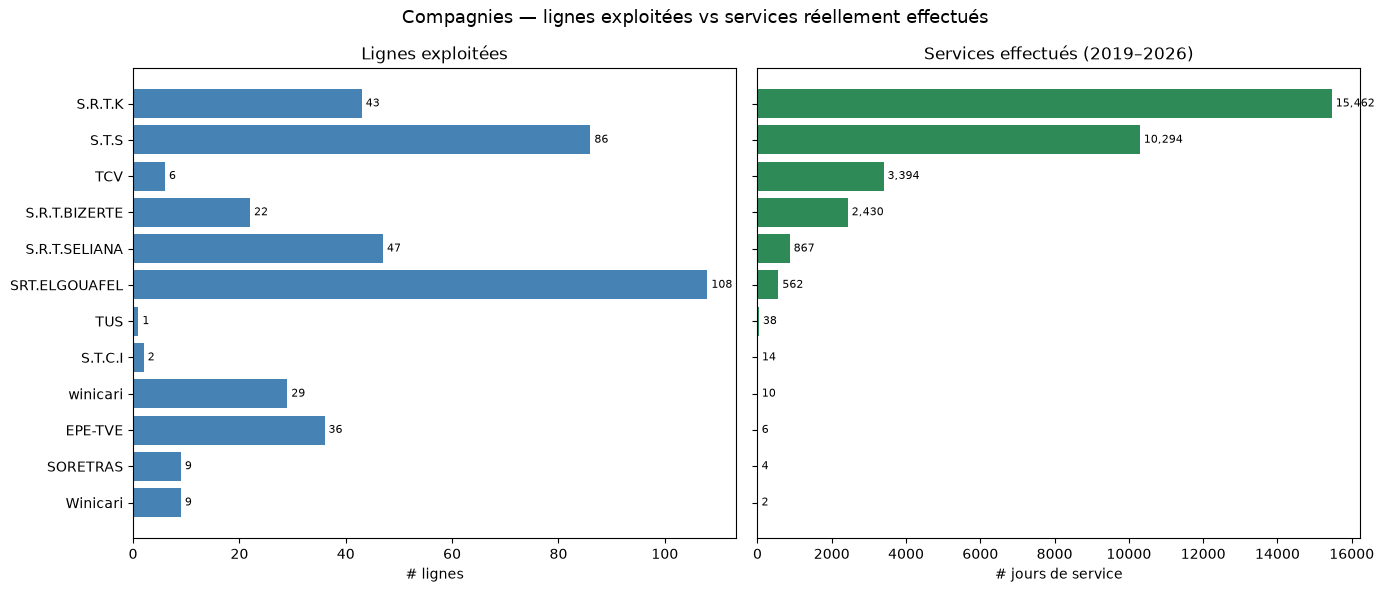

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
ax[0].barh(comp.index, comp["lines"], color="steelblue")
ax[0].set_title("Lignes exploitées"); ax[0].set_xlabel("# lignes")
for i, v in enumerate(comp["lines"]):
    ax[0].text(v, i, f" {v}", va="center", fontsize=8)

ax[1].barh(comp.index, comp["service_days"], color="seagreen")
ax[1].set_title("Services effectués (2019–2026)"); ax[1].set_xlabel("# jours de service")
for i, v in enumerate(comp["service_days"]):
    ax[1].text(v, i, f" {v:,}", va="center", fontsize=8)

plt.suptitle("Compagnies — lignes exploitées vs services réellement effectués", fontsize=13)
plt.tight_layout(); plt.show()

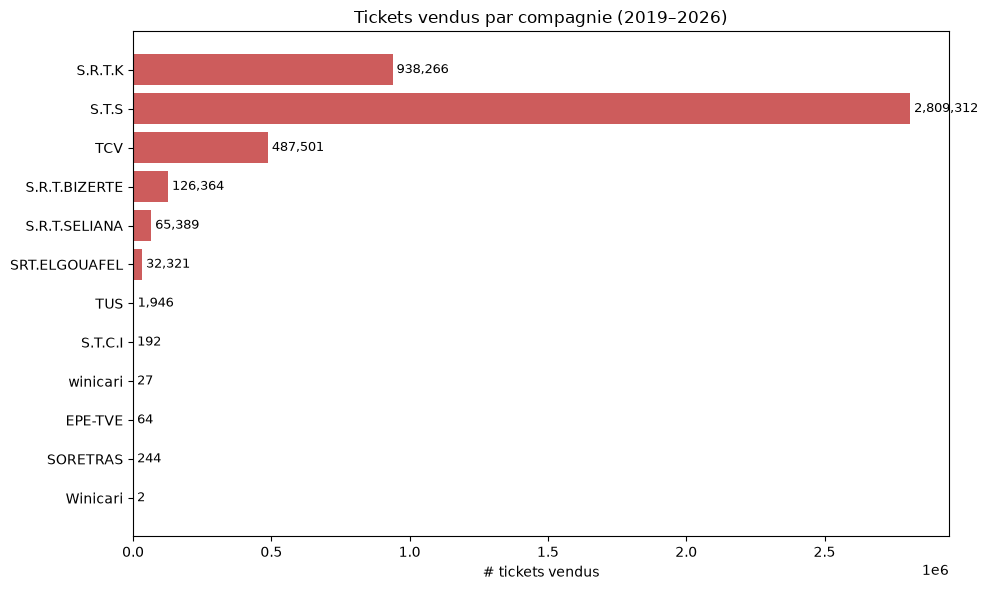

In [7]:
plt.figure(figsize=(10, 6))
plt.barh(comp.index, comp["tickets"], color="indianred")
plt.xlabel("# tickets vendus")
plt.title("Tickets vendus par compagnie (2019–2026)")
for i, v in enumerate(comp["tickets"]):
    plt.text(v, i, f" {v:,}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

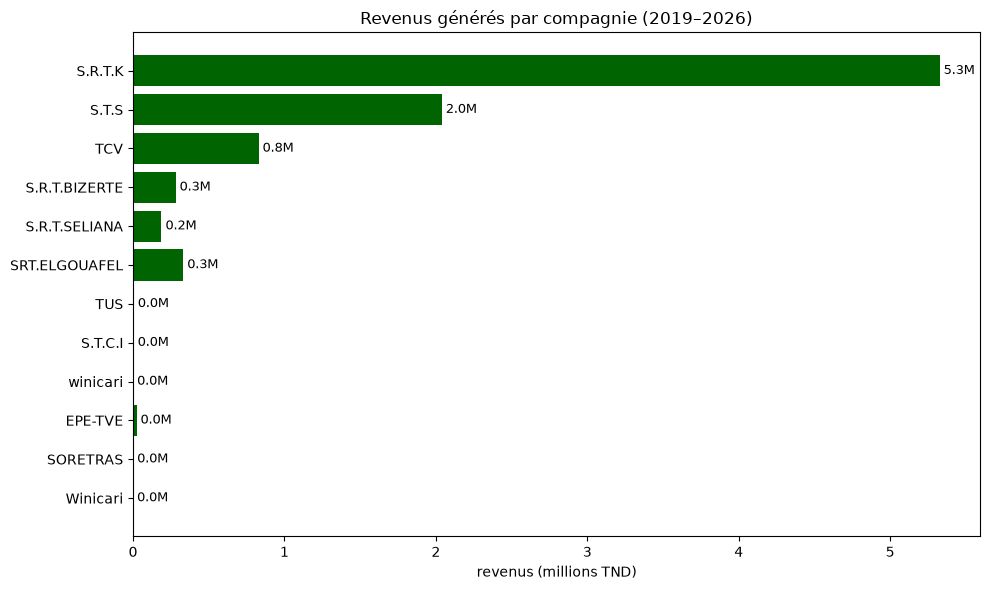

In [8]:
plt.figure(figsize=(10, 6))
plt.barh(comp.index, comp["recette"] / 1e6, color="darkgreen")  
plt.xlabel("revenus (millions TND)")
plt.title("Revenus générés par compagnie (2019–2026)")
for i, v in enumerate(comp["recette"] / 1e6):
    plt.text(v, i, f" {v:.1f}M", va="center", fontsize=9)
plt.tight_layout(); plt.show()

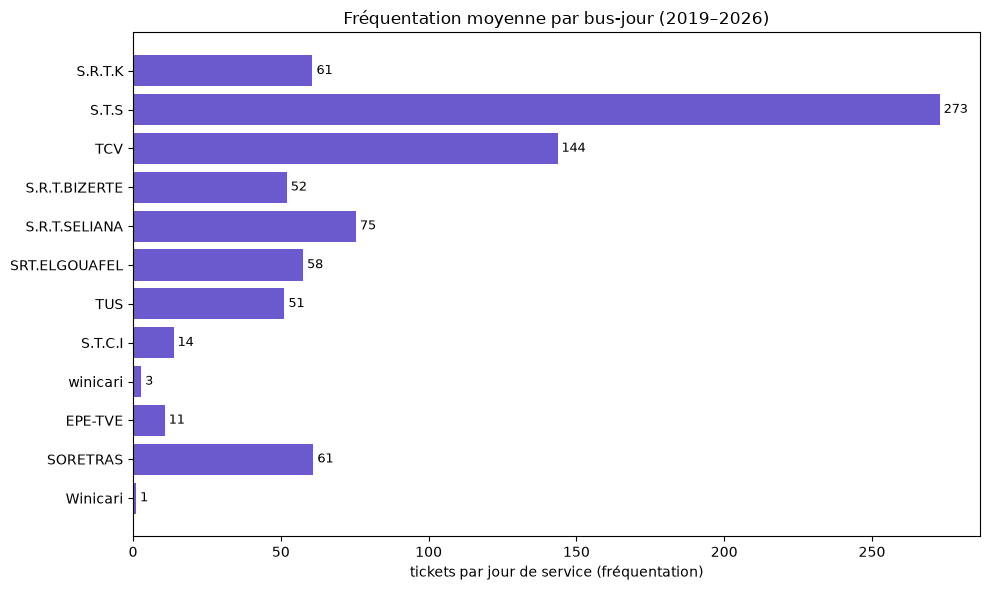

In [9]:
plt.figure(figsize=(10, 6))
plt.barh(comp.index, comp["tickets_per_service"], color="slateblue")
plt.xlabel("tickets par jour de service (fréquentation)")
plt.title("Fréquentation moyenne par bus-jour (2019–2026)")
for i, v in enumerate(comp["tickets_per_service"]):
    plt.text(v, i, f" {v:.0f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

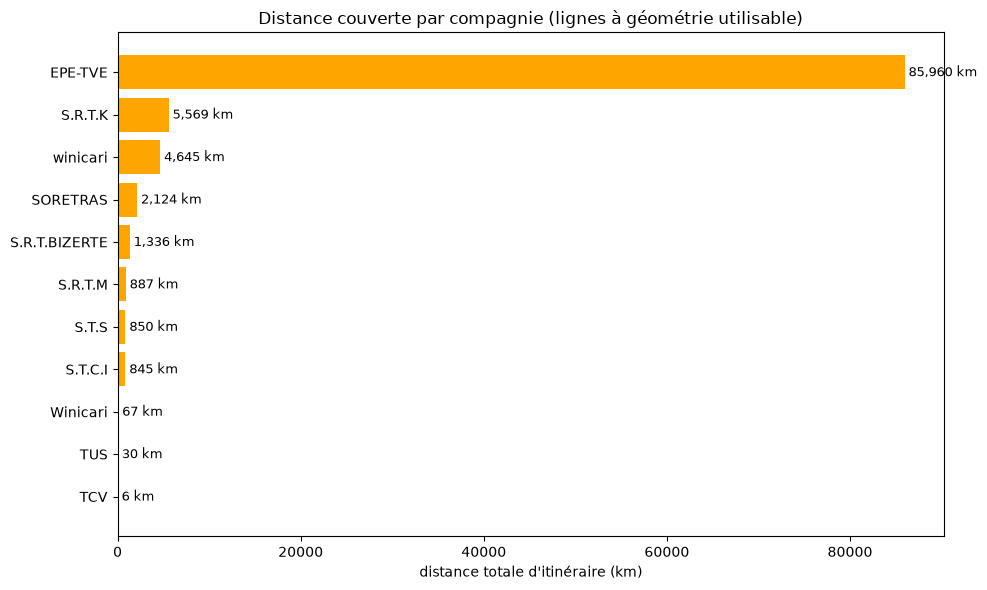

,lines,total_km
EPE-TVE,35.0,85959.640070
S.R.T.K,29.0,5569.321277
winicari,26.0,4644.891686
SORETRAS,9.0,2123.808358
S.R.T.BIZERTE,13.0,1335.840807
S.R.T.M,2.0,886.882150
S.T.S,15.0,850.084237
S.T.C.I,2.0,845.340949
Winicari,2.0,67.166855
TUS,1.0,30.455337


In [10]:
from src.data import foundation as fdn

cfg = fdn.Config()
usable = fdn.build_usable_lines(db_winicari, cfg)
dist = {}
for (code, soc), stops in usable.items():
    if soc not in dist:
        dist[soc] = {'lines': 0, 'total_km': 0.0}
    dist[soc]['lines'] += 1
    dist[soc]['total_km'] += stops['s_m'].max() / 1000.0

dist_df = pd.DataFrame(dist).T.sort_values('total_km', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(dist_df.index, dist_df['total_km'], color="orange")
plt.xlabel("distance totale d'itinéraire (km)")
plt.title("Distance couverte par compagnie (lignes à géométrie utilisable)")
for i, v in enumerate(dist_df['total_km']):
    plt.text(v, i, f" {v:,.0f} km", va="center", fontsize=9)
plt.tight_layout(); plt.show()

display(dist_df.sort_values('total_km', ascending=False))

In [11]:
import re
from datetime import date

gps_cols = []
for c in db_gps.list_collection_names():
    if re.fullmatch(r"d\d{8}", c):
        gps_cols.append(c)
gps_cols = sorted(gps_cols)

counts = {}
days = []
for c in gps_cols:
    counts[c] = db_gps[c].estimated_document_count()
    day = date(int(c[1:5]), int(c[5:7]), int(c[7:9]))
    days.append(day)

total = sum(counts.values())

print("Daily GPS collections:",len(gps_cols))
print("Date range:", days[0], "->", days[-1])
print("Total pings (est):",total)
print("Pings/day min/avg/max:", min(counts.values()), "/", total // len(gps_cols), "/", max(counts.values()))

# missing-day gaps
print("\nMissing-day gaps:")
for i in range(1, len(days)):
    diff = (days[i] - days[i-1]).days
    if diff > 1:
        print("   ", days[i-1], "->", days[i], "(", diff - 1, "days missing )")

Daily GPS collections: 1603
Date range: 2022-01-21 -> 2026-06-21
Total pings (est): 36346673
Pings/day min/avg/max: 1 / 22674 / 122413

Missing-day gaps:
    2025-01-11 -> 2025-01-18 ( 6 days missing )
    2025-06-05 -> 2025-06-07 ( 1 days missing )
    2025-08-23 -> 2025-08-25 ( 1 days missing )
    2026-03-27 -> 2026-03-30 ( 2 days missing )


In [12]:
print(gps_cols)

['d20220121', 'd20220122', 'd20220123', 'd20220124', 'd20220125', 'd20220126', 'd20220127', 'd20220128', 'd20220129', 'd20220130', 'd20220131', 'd20220201', 'd20220202', 'd20220203', 'd20220204', 'd20220205', 'd20220206', 'd20220207', 'd20220208', 'd20220209', 'd20220210', 'd20220211', 'd20220212', 'd20220213', 'd20220214', 'd20220215', 'd20220216', 'd20220217', 'd20220218', 'd20220219', 'd20220220', 'd20220221', 'd20220222', 'd20220223', 'd20220224', 'd20220225', 'd20220226', 'd20220227', 'd20220228', 'd20220301', 'd20220302', 'd20220303', 'd20220304', 'd20220305', 'd20220306', 'd20220307', 'd20220308', 'd20220309', 'd20220310', 'd20220311', 'd20220312', 'd20220313', 'd20220314', 'd20220315', 'd20220316', 'd20220317', 'd20220318', 'd20220319', 'd20220320', 'd20220321', 'd20220322', 'd20220323', 'd20220324', 'd20220325', 'd20220326', 'd20220327', 'd20220328', 'd20220329', 'd20220330', 'd20220331', 'd20220401', 'd20220402', 'd20220403', 'd20220404', 'd20220405', 'd20220406', 'd20220407'

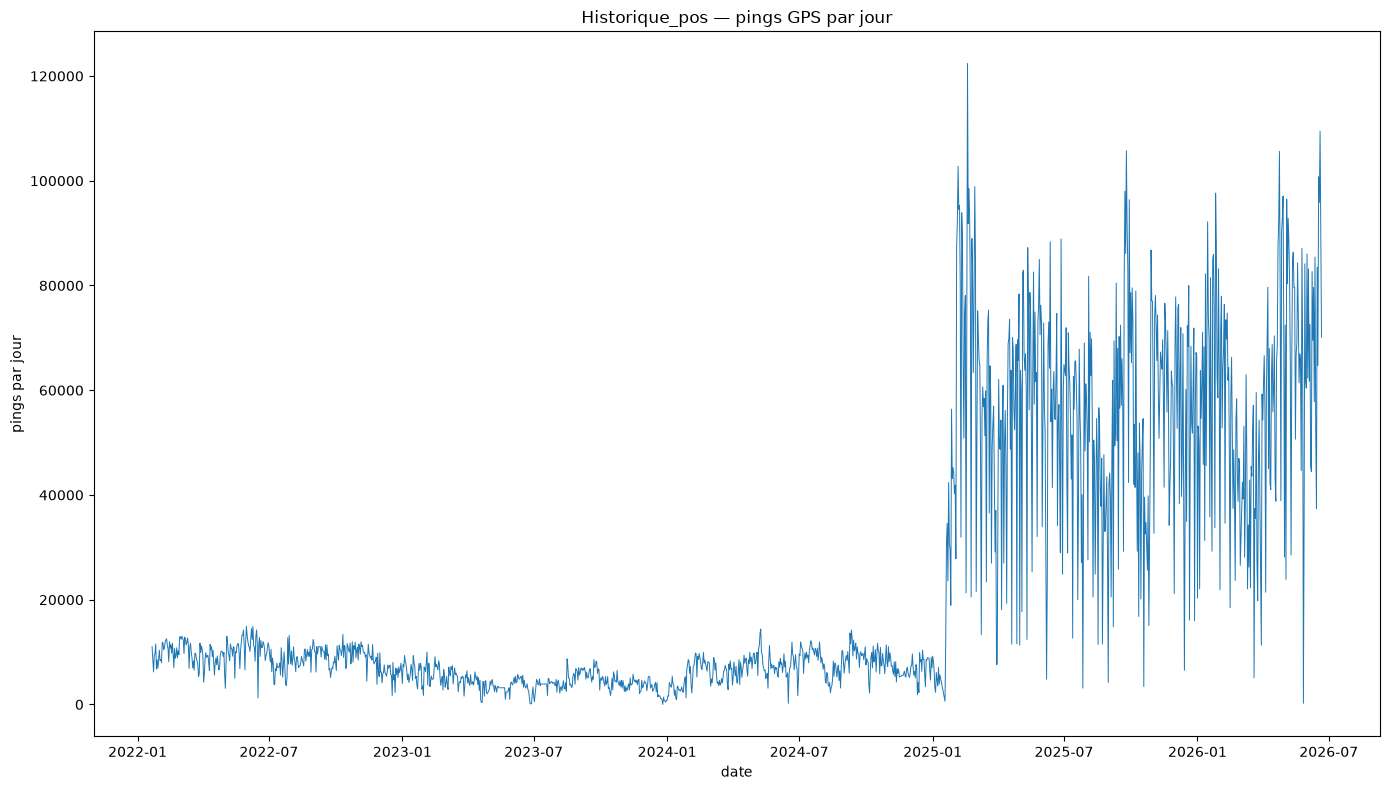

In [13]:
plt.figure(figsize=(14, 8))
plt.plot(days, [counts[c] for c in gps_cols], linewidth=0.7)
plt.ylabel("pings par jour")
plt.xlabel("date")
plt.title("Historique_pos — pings GPS par jour")
plt.tight_layout()
plt.show()

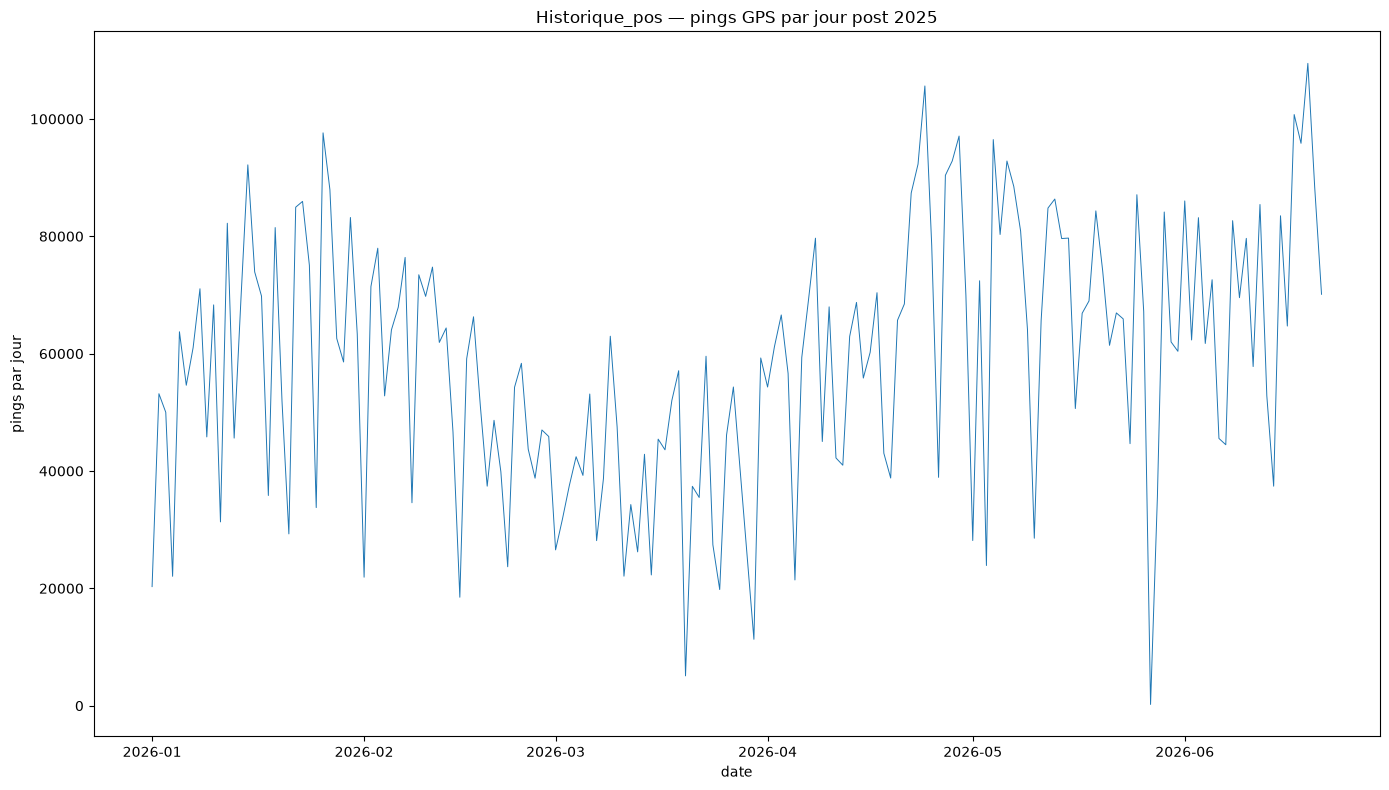

In [14]:
post2025 = [c for c in gps_cols if c > "d20251231"]
days_post2025 = []
for c in post2025:
    counts[c] = db_gps[c].estimated_document_count()
    day = date(int(c[1:5]), int(c[5:7]), int(c[7:9]))
    days_post2025.append(day)
plt.figure(figsize=(14, 8))
plt.plot(days_post2025, [counts[c] for c in post2025], linewidth=0.7)
plt.ylabel("pings par jour")
plt.xlabel("date")
plt.title("Historique_pos — pings GPS par jour post 2025")
plt.tight_layout()
plt.show()

In [15]:
daily = pd.DataFrame({"day": days, "pings": [counts[c] for c in gps_cols]})
daily["year"] = pd.to_datetime(daily["day"]).dt.year

yearly = daily.groupby("year").agg(
    days_with_data=("pings", "size"),
    total_pings=("pings", "sum"),
    avg_pings_per_day=("pings", "mean"),
).reset_index()
yearly["avg_pings_per_day"] = yearly["avg_pings_per_day"].round().astype(int)
yearly

,year,days_with_data,total_pings,avg_pings_per_day
0,2022,345,3178248,9212
1,2023,365,1603992,4394
2,2024,366,2638244,7208
3,2025,357,18901844,52946
4,2026,170,10024345,58967


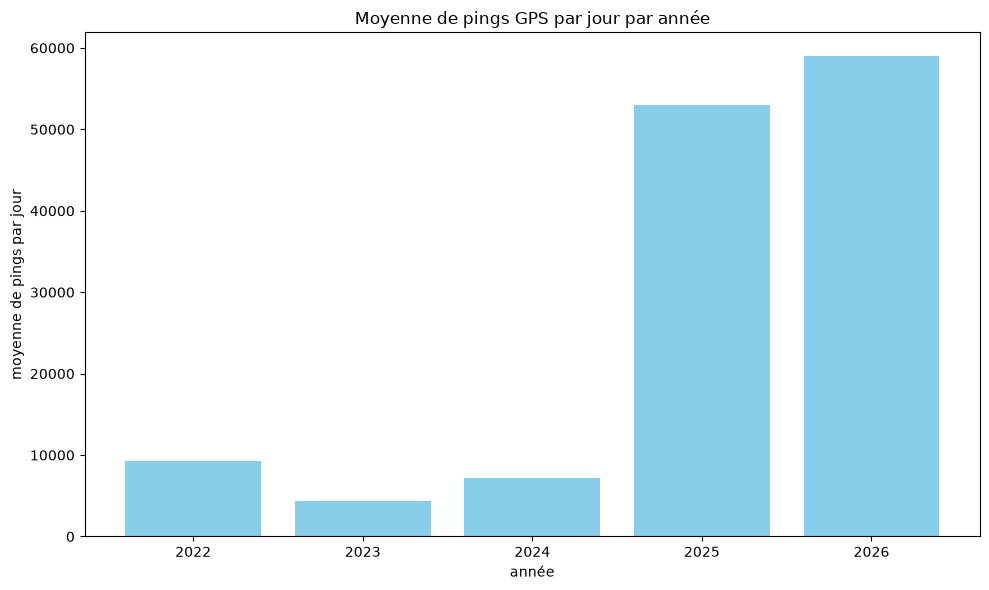

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(yearly["year"], yearly["avg_pings_per_day"], color="skyblue")
plt.xlabel("année")
plt.ylabel("moyenne de pings par jour")
plt.title("Moyenne de pings GPS par jour par année")
plt.tight_layout()
plt.show()

## Exploration de chaque collection

In [17]:
from collections import defaultdict
from IPython.display import display

def profile_collection(db, name, sample=300):
    # Sample docs and report, per field: % present, % null, type(s), an example value.
    coll = db[name]
    n_total = coll.estimated_document_count()
    if n_total == 0:
        print("---", name, "(empty) ---")
        return pd.DataFrame()
    docs = list(coll.aggregate([{"$sample": {"size": min(sample, n_total)}}]))
    n = len(docs)

    fields = defaultdict(lambda: {"present": 0, "null": 0, "types": set(), "example": None})
    for d in docs:
        for k, v in d.items():
            f = fields[k]
            f["present"] += 1
            if v is None:
                f["null"] += 1
            else:
                f["types"].add(type(v).__name__)
                if f["example"] is None:
                    f["example"] = v

    rows = []
    for k, f in fields.items():
        rows.append({
            "field": k,
            "present_%": round(100 * f["present"] / n),
            "null_%": round(100 * f["null"] / f["present"]),
            "types": ", ".join(sorted(f["types"])) or "null",
            "example": str(f["example"])[:45],
        })
    print("---", db.name + "." + name, "| est_count =", f"{n_total:,}", "| sampled =", n, "---")
    return pd.DataFrame(rows)

In [18]:
# Profile the collections that matter for the AI modules
for col in ["bus", "ligne", "station", "service", "ticket", "panne", "details"]:
    display(profile_collection(db_winicari, col))

--- winicari.bus | est_count = 772 | sampled = 300 ---


,field,present_%,null_%,types,example
0,_id,100,0,ObjectId,6023a8e3ef3f0000f200695f
1,code,100,0,int,283
2,matricule,100,0,str,
3,vitesseMax,100,0,str,90
4,societe,100,0,str,S.T.S
5,nbrPlace,100,0,str,54
6,dateAjout,100,0,str,10/02/2021
7,active,97,0,bool,False
8,distanceParc,99,0,"float, int",0
9,distanceParcAncien,98,0,"float, int",0


--- winicari.ligne | est_count = 402 | sampled = 300 ---


,field,present_%,null_%,types,example
0,_id,100,0,ObjectId,5d32df245c6a97d8053ea095
1,code,100,0,str,411
2,correspendance,100,0,str,411
3,orfr,98,0,str,RAS JEBAL
4,orar,98,0,str,راس الجبل
5,desfr,98,0,str,BIZERTE VIA METLINE
6,desar,98,0,str,بنزرت عبر متلين
7,nbrstations,100,0,"int, str",8
8,societe,100,0,str,S.R.T.BIZERTE
9,stationnames,15,0,list,"['RAS JEBAL', 'BENI ATTA', 'METLINE', 'S.ALI"


--- winicari.station | est_count = 289 | sampled = 289 ---


...

,field,present_%,null_%,types,example
0,_id,100,0,ObjectId,6a34ed83143f770990f8f93a
1,idTicket,100,0,int,168
2,codeLigne,100,0,str,31
3,codeCh,100,0,str,1611
4,codeConv,100,0,str,1611
5,codeCentre,100,0,str,22
6,ligne,100,0,str,
7,nomFR1,100,0,str,Sidi Bou Sid
8,nomAR1,100,0,str,سيدي بوزيد
9,nomFR2,100,0,str,Ben Oune


--- winicari.panne | est_count = 453 | sampled = 300 ---


,field,present_%,null_%,types,example
0,_id,100,0,ObjectId,6a1d9aae79550000ef002f02
1,bus,100,0,str,6039
2,chauffeur,100,0,str,6026
3,conv,100,0,str,6026
4,type,100,0,str,
5,nom,100,0,str,OSTICKET
6,codeco,100,0,str,9999
7,nserie,100,0,str,BS-18-0010
8,date,100,0,str,20260601
9,heur,100,0,str,0815


--- winicari.details | est_count = 7,881 | sampled = 300 ---


,field,present_%,null_%,types,example
0,_id,100,0,ObjectId,68a72e59e596cc8cdc0d6d42
1,societe,100,2,str,S.T.S
2,appareil,100,2,str,BS-19-0008
3,date,100,0,str,2025/08/21
4,codeConv,100,0,str,5531
5,codeCh,100,0,str,5531
6,CodeLigne,100,0,str,211
7,codeCentre,100,0,str,00
8,codeBus,100,0,int,788
9,nbrTicket,100,0,int,147


### Le format du ping GPS a évolué dans le temps (résultat clé)

Les documents GPS par jour ne sont **pas** tous identiques. Des champs ont été ajoutés à différentes
époques. Cela est très important pour le **Repli GPS** (où lire la vitesse ?) et le **Retard**

In [19]:
drift_days = ["d20220121", "d20230101", "d20240101", "d20250101",
              "d20250601", "d20260101", "d20260601"]

rows = []
for s in drift_days:
    docs = list(db_gps[s].find().limit(300))
    n = len(docs)
    sp = sum("speed" in d for d in docs)
    sv = sum("service" in d for d in docs)
    di = sum("direction" in d for d in docs)
    rows.append({
        "collection": s,
        "speed_present_%": round(100 * sp / n),
        "service_present_%": round(100 * sv / n),
        "direction_present_%": round(100 * di / n),
        "speed_null_%": round(100 * sum(d.get("speed") is None for d in docs) / sp) if sp else None,
        "direction_null_%": round(100 * sum(d.get("direction") is None for d in docs) / di) if di else None,
    })

gps_drift = pd.DataFrame(rows)
gps_drift

,collection,speed_present_%,service_present_%,direction_present_%,speed_null_%,direction_null_%
0,d20220121,0,0,0,NaN,NaN
1,d20230101,0,100,0,NaN,NaN
2,d20240101,0,100,0,NaN,NaN
3,d20250101,0,100,0,NaN,NaN
4,d20250601,100,100,100,0.0,0.0
5,d20260101,100,100,100,0.0,44.0
6,d20260601,100,100,100,0.0,98.0


**Lecture du tableau**

- `localisation` est `{x: latitude, y: longitude}` dans **toutes** les époques (nommage déroutant).
- **Vitesse** : un champ `speed` de niveau supérieur n'apparaît qu'à partir de **début 2025**. Mais la vitesse est
  disponible sur toute l'**histoire** via `bus.vitesse` (km/h calculé)
  — pour le Repli, utiliser `bus.vitesse` comme source universelle.
- **Lien de ligne** (`service.codeLigne`) est présent à partir de **mi-2022** (manquant
  seulement les premières semaines de 2022) — utilisable pour la prédiction de Retard.
- **`direction` (cap) est peu fiable** : taux de valeurs nulles atteignant **98 %** sur certains jours
  2026. Ne pas en dépendre ; recalculer le cap à partir de positions consécutives si nécessaire.

### Billetterie — seulement 1 semaine de tickets bruts, preuve de concept

On peut quand même voir la **courbe de demande par heure** et construire un **proxy de surcharge**
= embarquements quotidiens par trajet ÷ places. Attention : c'est les *embarquements totaux journaliers*
vs capacité, **pas** l'occupation simultanée (l'occupation réelle nécessite une modélisation
origine/destination le long de la route).

Plage de tickets bruts : 2026-06-16 01:42:00.598000 -> 2026-06-22 13:32:00.842000 | lignes : 13401 | bus : 35 | lignes : 33 | compagnies : 5
Ventes moyennes de tickets par trajet : 26.965656565656566


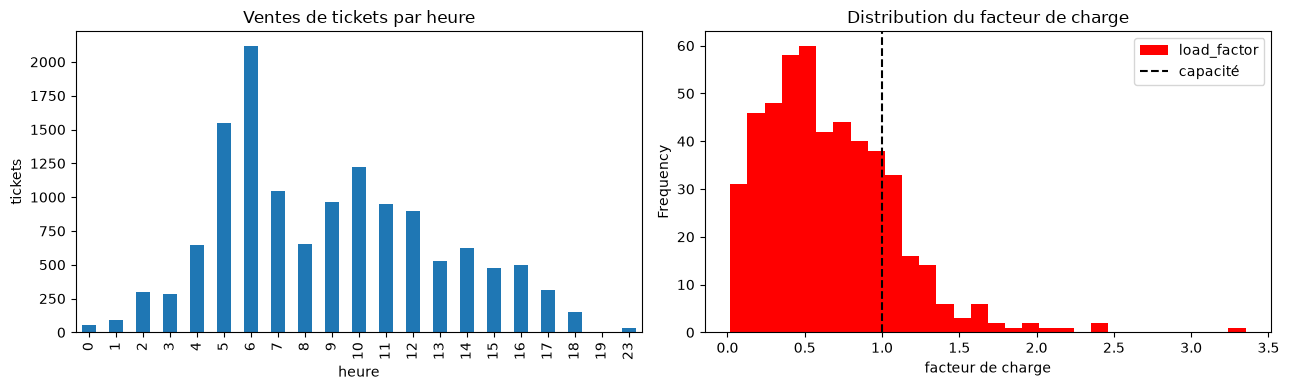

Trajets au-dessus de la capacité (facteur > 1) : 88 sur 495


In [20]:
tk = pd.DataFrame(list(db_winicari["ticket"].find({}, {
    "idTicket": 1,
    "codeLigne": 1,
    "codeCh": 1,
    "voyage": 1,
    "prix": 1,
    "date": 1,
    "bus.code": 1,
    "bus.nbrPlace": 1,
    "bus.societe": 1,
    "_id": 0
})))

tk["bus_code"] = tk["bus"].apply(lambda b: b.get("code") if isinstance(b, dict) else None)
tk["seats"] = tk["bus"].apply(lambda b: b.get("nbrPlace") if isinstance(b, dict) else None)
tk["societe"] = tk["bus"].apply(lambda b: b.get("societe") if isinstance(b, dict) else None)

tk["seats"] = pd.to_numeric(tk["seats"], errors="coerce")

tk = tk.drop(columns=["bus"])

tk["date"] = pd.to_datetime(tk["date"])
tk["hour"] = tk["date"].dt.hour
tk["day"] = tk["date"].dt.date

print(
    "Plage de tickets bruts :", tk["date"].min(), "->", tk["date"].max(),
    "| lignes :", len(tk),
    "| bus :", tk["bus_code"].nunique(),
    "| lignes :", tk["codeLigne"].nunique(),
    "| compagnies :", tk["societe"].nunique()
)

trip = tk.groupby(["bus_code", "day", "codeCh", "voyage"]).agg(
    boardings=("idTicket", "count"),
    seats=("seats", "first"),
    societe=("societe", "first")
).reset_index()

trip["load_factor"] = trip["boardings"] / trip["seats"]

mean_boardings = trip["boardings"].mean()

print("Ventes moyennes de tickets par trajet :", mean_boardings)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

tk.groupby("hour").size().plot(kind="bar", ax=ax[0])
ax[0].set_title("Ventes de tickets par heure")
ax[0].set_xlabel("heure")
ax[0].set_ylabel("tickets")

trip["load_factor"].plot(kind="hist", bins=30, ax=ax[1], color="red")
ax[1].axvline(1.0, color="black", ls="--", label="capacité")
ax[1].set_title("Distribution du facteur de charge")
ax[1].set_xlabel("facteur de charge")
ax[1].legend()

plt.tight_layout()
plt.show()

print(
    "Trajets au-dessus de la capacité (facteur > 1) :",
    int((trip["load_factor"] > 1).sum()),
    "sur",
    len(trip)
)

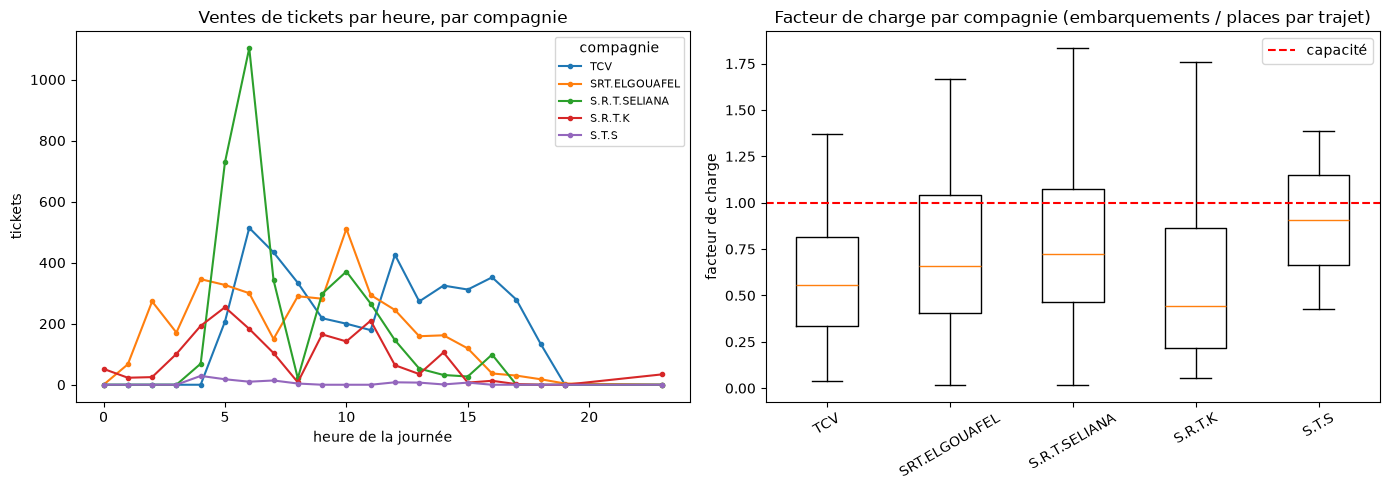

,bus_runs,mean_load,median_load,over_capacity,pct_over_capacity
societe,,,,,
S.T.S,2,0.91,0.91,1,50.0
S.R.T.SELIANA,81,0.81,0.72,25,31.0
SRT.ELGOUAFEL,94,0.75,0.66,24,26.0
TCV,262,0.59,0.56,28,11.0
S.R.T.K,56,0.57,0.44,10,18.0


In [21]:
companies = tk.dropna(subset=["societe"])["societe"].value_counts().index.tolist()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

by_hour = (tk.dropna(subset=["societe"]).groupby(["hour", "societe"]).size()
             .unstack(fill_value=0)[companies])
by_hour.plot(ax=ax[0], marker="o", ms=3)
ax[0].set_title("Ventes de tickets par heure, par compagnie")
ax[0].set_xlabel("heure de la journée"); ax[0].set_ylabel("tickets")
ax[0].legend(title="compagnie", fontsize=8)

trip_c = trip.dropna(subset=["societe"])
data = [trip_c.loc[trip_c["societe"] == s, "load_factor"].values for s in companies]
ax[1].boxplot(data, tick_labels=companies, showfliers=False)
ax[1].axhline(1.0, color="red", ls="--", label="capacité")
ax[1].set_title("Facteur de charge par compagnie (embarquements / places par trajet)")
ax[1].set_ylabel("facteur de charge"); ax[1].tick_params(axis="x", rotation=30); ax[1].legend()
plt.tight_layout(); plt.show()

summary = (trip_c.groupby("societe")
           .agg(bus_runs=("load_factor", "size"),
                mean_load=("load_factor", "mean"),
                median_load=("load_factor", "median"),
                over_capacity=("load_factor", lambda s: int((s > 1).sum())))
           .round(2)
           .sort_values("mean_load", ascending=False))
summary["pct_over_capacity"] = (100 * summary["over_capacity"] / summary["bus_runs"]).round(0)
display(summary)

### Pannes (`panne`) — courtes et sans étiquettes, mais utilisables comme labels d'anomalie faibles

Seulement 5 mois, concentrées avr–juin 2026, et `type` est presque toujours vide. Néanmoins,
les **horodatages + identifiants de bus** sont de vrais exemples positifs : on les croise avec
la trace GPS de ce bus pour valider un détecteur « bus arrêté / anormal ».

pannes : 453 | plage : 2026-01-24 11:02:00 -> 2026-06-22 13:44:00 | 'type' renseigné : 1 sur 453


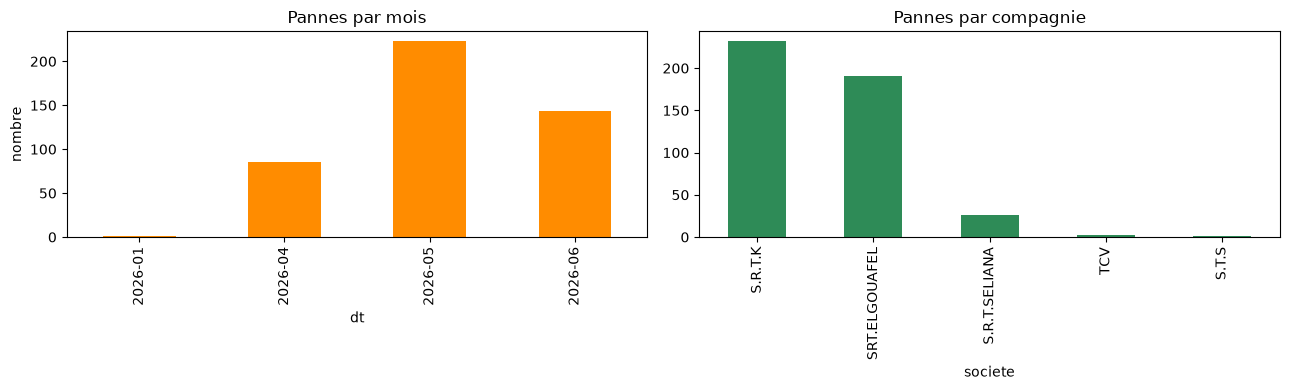

In [22]:
pn = pd.DataFrame(list(db_winicari["panne"].find({}, {"_id": 0})))
pn["dt"] = pd.to_datetime(pn["date"] + pn["heur"].str.zfill(4), format="%Y%m%d%H%M", errors="coerce")
bus2soc = {str(b["code"]): b.get("societe") for b in db_winicari["bus"].find({}, {"code": 1, "societe": 1})}
pn["societe"] = pn["bus"].astype(str).map(bus2soc)
print("pannes :", len(pn), "| plage :", pn["dt"].min(), "->", pn["dt"].max(),
      "| 'type' renseigné :", int((pn["type"].str.strip() != "").sum()), "sur", len(pn))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
pn["dt"].dt.to_period("M").astype(str).value_counts().sort_index().plot(kind="bar", ax=ax[0], color="darkorange")
ax[0].set_title("Pannes par mois"); ax[0].set_ylabel("nombre")
pn["societe"].value_counts(dropna=False).plot(kind="bar", ax=ax[1], color="seagreen")
ax[1].set_title("Pannes par compagnie")
plt.tight_layout(); plt.show()